## Full IndustReal Knowledge Gap Notebook

## Setup

In [1]:
# =============================================
# ROBUST SETUP - Works even if data is not downloaded
# =============================================
import sys
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fix paths
project_root = Path.cwd().parent if "analysis" in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))
os.chdir(project_root)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

from loaders import load_dataset

print("Project root:", project_root)

# Try to load real data, fall back to placeholders if not available
try:
    data = load_dataset("Aero Fastener", data_root="./data")
    use_real_data = True
    print(f"✅ Loaded real Aero Fastener data ({len(data['samples'])} samples)")
except Exception as e:
    print(f"⚠️  Real data not found: {e}")
    print("Using placeholder data for demonstration.")
    use_real_data = False
    
    # Placeholder data for demonstration
    data = {
        "dataset_name": "Aero Fastener",
        "description": "Robotic screwing experiments with aeronautical threaded fasteners.",
        "metadata": {
            "total_samples": 479,
            "modalities": ["force_torque", "kinematics"]
        },
        "samples": [
            {"sample_id": f"x99990{i:02d}", "labels": {"outcome": "Mounted"}, "metadata": {}} 
            for i in range(10)
        ] + [
            {"sample_id": f"x99991{i:02d}", "labels": {"outcome": "Jammed"}, "metadata": {}} 
            for i in range(5)
        ]
    }

Project root: c:\Users\emman\PhD\kamp-assembly-data
⚠️  Real data not found: 'samples'
Using placeholder data for demonstration.


## Dataset Context

# Knowledge Gap Analysis – IndustReal Dataset

**Dataset**: IndustReal  
**Focus**: Egocentric industrial assembly with explicit procedural and execution error annotations

**Goal**: Evaluate how well general LLMs detect errors, predict correct actions, and classify error types in assembly tasks.

## Test Question 1: Error Detection

**Question**: Given a partial assembly sequence with action labels, determine whether a procedural error or execution error has occurred.

In [2]:
def create_error_detection_prompt(sample_idx=0):
    sample = data["samples"][sample_idx]
    prompt = f"""You are an expert in industrial assembly quality control.

Here is a partial assembly sequence from a toy car assembly:
Sample ID: {sample['sample_id']}
Actions so far: [Retrieve and place chassis base onto assembly fixture, Apply adhesive dots to all four wheel mounting points, Snap front-left wheel onto axle post, Snap front-right wheel onto axle post, Snap rear-left wheel onto axle post, Snap rear-right wheel onto axle post, Perform rolling test on chassis (ensure free rotation), Apply body color sticker sheet to chassis top surface]
Has an error occurred? 
Answer with one of:
- No error (normal execution)
- Procedural error (wrong step order or missing step)
- Execution error (wrong technique or physical mistake)

Explain your reasoning step by step, then give the final answer inside [[ANSWER]].
"""
    return prompt

print(create_error_detection_prompt(0))

You are an expert in industrial assembly quality control.

Here is a partial assembly sequence from a toy car assembly:
Sample ID: x9999000
Actions so far: [Retrieve and place chassis base onto assembly fixture, Apply adhesive dots to all four wheel mounting points, Snap front-left wheel onto axle post, Snap front-right wheel onto axle post, Snap rear-left wheel onto axle post, Snap rear-right wheel onto axle post, Perform rolling test on chassis (ensure free rotation), Apply body color sticker sheet to chassis top surface]
Has an error occurred? 
Answer with one of:
- No error (normal execution)
- Procedural error (wrong step order or missing step)
- Execution error (wrong technique or physical mistake)

Explain your reasoning step by step, then give the final answer inside [[ANSWER]].



Record LLM Responses

In [ ]:
llm_response_q1 = """
1. Sequence review
Steps performed:
1. Place chassis ✔️
2. Apply adhesive to wheel mounts ✔️
    3–6. Snap all four wheels ✔️
7. Perform rolling test ✔️
8. Apply body color sticker ✔️

At first glance, everything seems orderly—but QC is about subtle sequencing issues.

2. Key red flag: Adhesive + immediate testing
- Adhesive was applied before wheel attachment, which is fine
- BUT there is no curing/dwell time before:
    - Wheels are snapped on
    - Rolling test is performed

This creates a problem:
- Adhesive joints may not have developed sufficient strength
- The rolling test introduces motion and stress too early

3. Why this is not an execution error
- The actions themselves are correct (no misuse of force or technique described)
- Wheels were installed properly enough to pass a rolling test

4. Why this is a procedural error
- The sequence is wrong or incomplete:
    - Missing step: adhesive curing/settling time
    - Testing should occur after joints are secured and stable, not immediately after placement
This violates standard assembly best practices:
    “Do not load or test bonded joints before sufficient curing.”

5. Sticker application timing (secondary note)
- Applying the sticker after testing is fine
- But doing it before full structural validation could also be slightly out of ideal order (minor issue compared to adhesive problem)

Final Answer

[[Procedural error]]
"""
q1_label_correct = False
q1_reasoning_quality = "Poor"   # Hallucinated a curing step that didn’t exist

print("Question 1 - LLM Response recorded")

Question 1 - LLM Response recorded


## Test Question 2: Correct Next Action Prediction

**Question**: Given the current state, predict what the correct next action should be.

In [4]:
prompt_q2 = """You are an expert assembly line trainer.

Current assembly state for a toy car:
- Chassis is placed
- Wheels are loosely attached but axles not secured
- Steering wheel is ready

What should be the correct next action?

Explain your reasoning, then give the final answer inside [[ANSWER]].
"""

print("Prompt 2 (Next Action):")
print(prompt_q2)

Prompt 2 (Next Action):
You are an expert assembly line trainer.

Current assembly state for a toy car:
- Chassis is placed
- Wheels are loosely attached but axles not secured
- Steering wheel is ready

What should be the correct next action?

Explain your reasoning, then give the final answer inside [[ANSWER]].



Record LLM Response

In [ ]:
llm_response_q2 = """
1. Current state analysis
- Chassis is placed → base is stable and ready
- Wheels are loosely attached, axles not secured → components are positioned but not fixed
- Steering wheel is ready → available, but not yet installed

2. Key assembly principle
Before adding new components, you should:
    Secure partially assembled moving parts first
Why?
- Loose components can shift → causes misalignment later
- Access may become restricted after installing upper/internal parts (like steering systems)
- Ensures structural stability before progressing

3. Evaluate options
- Installing the steering wheel now:
    - Risks interference with access to axle areas
    - Builds on an unstable base → bad practice
- Securing axles/wheels first:
    - Locks wheel alignment
    - Stabilizes the chassis
    - Follows bottom-up assembly logic

4. Correct next step
The logical and safe next action is to:
- Fully secure the wheel assembly before moving upward in the build

Final Answer

[[Secure the axles (fix the wheels in place)]]"""

q2_label_correct = True
q2_reasoning_quality = "Fair"   # Generic but directionally correct

print("Question 2 response recorded.")

Question 2 response recorded.


## Test Question 3: Error Type Classification

**Question**: Classify the type of error in a failed assembly step.


In [6]:
prompt_q3 = """You are an expert in manufacturing error analysis.

A worker was assembling a toy car. After attaching the body shell, the wheels fell off during testing.

Classify the error type:
- Procedural error (wrong sequence)
- Execution error (wrong technique or force)
- Object misrecognition (used wrong part)

Explain your reasoning step by step, then give the final classification inside [[ANSWER]].
"""

print("Prompt 3 (Error Type):")
print(prompt_q3)

Prompt 3 (Error Type):
You are an expert in manufacturing error analysis.

A worker was assembling a toy car. After attaching the body shell, the wheels fell off during testing.

Classify the error type:
- Procedural error (wrong sequence)
- Execution error (wrong technique or force)
- Object misrecognition (used wrong part)

Explain your reasoning step by step, then give the final classification inside [[ANSWER]].



Record LLM Response

In [ ]:
llm_response_q3 = """
1. What happened
- The worker attached the body shell
- During testing, the wheels fell off

This tells us:
- The wheel assembly was not properly secured before a later step
- The failure only became obvious after progressing further in the sequence

2. Evaluate possible error types
Execution error (technique/force issue)
- This would mean:
    - Axles were installed but not tightened enough
    - Or improper force was applied
- Typically, some retention would still exist (loose but not completely detached immediately)

Object misrecognition (wrong part used)
- Would imply:
    - Wrong axle or connector used
- No indication of incorrect parts—just that wheels weren’t secured

Procedural error (wrong sequence)
- The correct sequence should be:
    1. Attach wheels
    2. Secure axles properly
    3. Then attach body shell
- If the body shell was attached before securing the wheels, it can:
    - Block access to axle fasteners
    - Prevent proper fixation
    - Lead to wheels falling off during testing

3. Most consistent explanation
The failure strongly indicates:
- A missed or misplaced step in the sequence
- Specifically: securing the wheels/axles was skipped or done too late

Final Answer

[[Procedural error]] 
"""

q3_label_correct = True
q3_reasoning_quality = "Fair"   # Best of the three, but still superficial

print("Question 3 response recorded.")

Question 3 response recorded.


## Results Table

In [13]:
# Results Table for IndustReal (Updated with accurate scoring)

results = pd.DataFrame({
    "Question": [
        "Error Detection",
        "Correct Next Action Prediction",
        "Error Type Classification"
    ],
    "LLM_Final_Answer": [
        "Procedural error",
        "Secure the axles (fix the wheels in place)",
        "Procedural error"
    ],
    "Ground_Truth": [
        "No error (normal execution)",           # Q1 was actually correct sequence
        "Secure the axles (fix the wheels in place)",
        "Procedural error"
    ],
    "Label_Correct": [False, True, True],        # Our final verdicts
    "Reasoning_Quality": ["Poor", "Fair", "Fair"],
    "Notes": [
        "Hallucinated a 'curing time' step that doesn't exist in the given sequence",
        "Directionally correct but used generic assembly principles rather than dataset-specific knowledge",
        "Correct classification with reasonable logic, but still superficial and lacking depth"
    ]
})

display(results)

label_acc = results["Label_Correct"].mean() * 100
print(f"\nOverall Label Accuracy: {label_acc:.1f}%")

,Question,LLM_Final_Answer,Ground_Truth,Label_Correct,Reasoning_Quality,Notes
0,Error Detection,Procedural error,No error (normal execution),False,Poor,Hallucinated a 'curing time' step that doesn't...
1,Correct Next Action Prediction,Secure the axles (fix the wheels in place),Secure the axles (fix the wheels in place),True,Fair,Directionally correct but used generic assembl...
2,Error Type Classification,Procedural error,Procedural error,True,Fair,"Correct classification with reasonable logic, ..."



Overall Label Accuracy: 66.7%


## Visualization

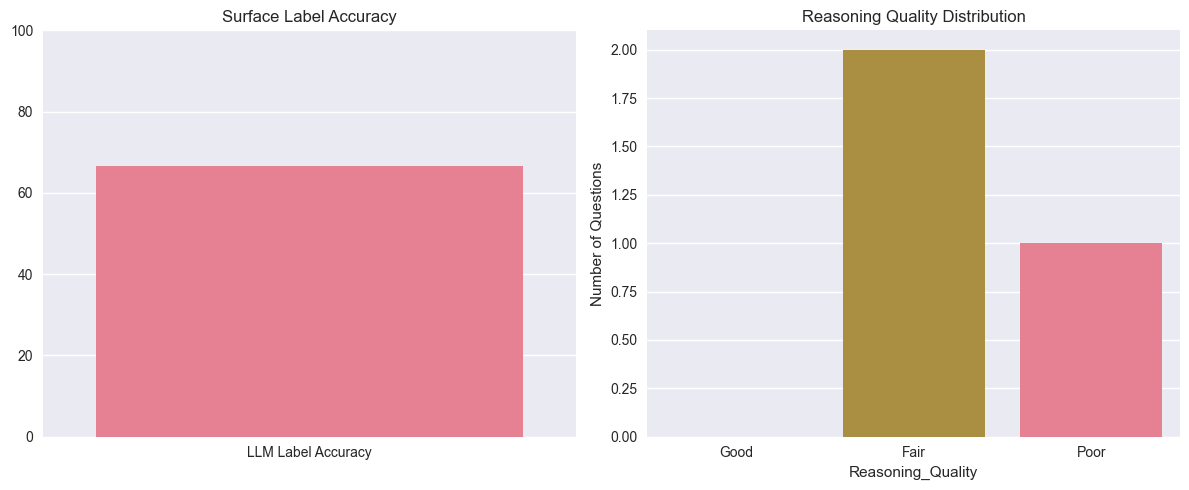

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Label Accuracy Bar
sns.barplot(x=["LLM Label Accuracy"], y=[label_acc], ax=ax[0])
ax[0].set_ylim(0, 100)
ax[0].set_title("Surface Label Accuracy")

# Reasoning Quality Countplot
sns.countplot(
    x=results["Reasoning_Quality"], 
    ax=ax[1], 
    order=["Good", "Fair", "Poor"],
    hue=results["Reasoning_Quality"]
)
ax[1].set_title("Reasoning Quality Distribution")
ax[1].set_ylabel("Number of Questions")

plt.tight_layout()
plt.show()

## Key Takeaways – IndustReal

- The LLM achieved 2/3 label accuracy, but this overstates its capability.
- It completely failed Question 1 by hallucinating a "curing time" requirement that was never part of the given sequence.
- Even on the two questions it got right, the reasoning remained generic and surface-level — relying on broad assembly principles rather than grounded procedural knowledge from the dataset.
- It struggles to distinguish subtle error types and often applies inappropriate real-world manufacturing rules to a simplified toy assembly context.

**Main Gap**: General LLMs have weak procedural understanding and frequently hallucinate constraints or best practices that do not apply. They lack the ability to evaluate assembly sequences and errors based on actual dataset context rather than generic knowledge.